<a href="https://colab.research.google.com/github/Palamarovski/Google-colab/blob/main/lab7_Palamar_Mykola.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

1.Завантажте набір даних. 2.Виведіть заголовок таблиці (перші 5 записів)

In [2]:
import pandas as pd

# Завантажуємо набір даних
df = pd.read_csv('creditcard_b.csv')

# Виводимо перші 5 записів
print("Перші 5 записів:")
display(df.head())

Перші 5 записів:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class,Type
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,0,Terminal
1,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,0,Online
2,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,0,Mobile
3,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,0,Online
4,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0,Terminal


3.В якому форматі мітки класів? 4.В якому форматі характеристики об’єктів?

In [3]:
# 3. Формат міток класів
print(f"Формат міток класів: {df['Class'].dtype}")

# 4. Формат характеристик та факторизація
print("\nФормати всіх стовпців:")
print(df.dtypes)

# Перевіряємо наявність тексту та факторизуємо (якщо є)
for col in df.columns:
    if df[col].dtype == 'object':
        print(f"\nФакторизуємо текстовий стовпець: {col}")
        df[col] = pd.factorize(df[col])[0]

print("\nДані після факторизації:")
display(df.head())

Формат міток класів: int64

Формати всіх стовпців:
V1       float64
V2       float64
V3       float64
V4       float64
V5       float64
V6       float64
V7       float64
V8       float64
V9       float64
V10      float64
Class      int64
Type      object
dtype: object

Факторизуємо текстовий стовпець: Type

Дані після факторизації:


,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,Class,Type
0,0.496714,-0.138264,0.647689,1.523030,-0.234153,-0.234137,1.579213,0.767435,-0.469474,0.542560,0,0
1,-0.463418,-0.465730,0.241962,-1.913280,-1.724918,-0.562288,-1.012831,0.314247,-0.908024,-1.412304,0,1
2,1.465649,-0.225776,0.067528,-1.424748,-0.544383,0.110923,-1.150994,0.375698,-0.600639,-0.291694,0,2
3,-0.601707,1.852278,-0.013497,-1.057711,0.822545,-1.220844,0.208864,-1.959670,-1.328186,0.196861,0,1
4,0.738467,0.171368,-0.115648,-0.301104,-1.478522,-0.719844,-0.460639,1.057122,0.343618,-1.763040,0,0


5. Наскільки збалансовані класи? 6. Створити навчальний набір предикторів X та цілей Y. Перетворити мітки класів
до формату One hot encoding.


In [4]:
from tensorflow.keras.utils import to_categorical

# 5. Перевірка збалансованості класів
print("Кількість записів кожного класу:")
print(df['Class'].value_counts())

# 6. Створення X та Y + One Hot Encoding для міток
X = df.drop('Class', axis=1).values
Y = to_categorical(df['Class'])

print("\nМітки класу перетворено у формат One Hot Encoding.")

Кількість записів кожного класу:
Class
0    950
1     50
Name: count, dtype: int64

Мітки класу перетворено у формат One Hot Encoding.


7. Розбити набір даних на навчальну та тестову множини.8. Стандартизувати предиктори X.

In [5]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 7. Розбиття на навчальну та тестову множини
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

# 8. Стандартизація предикторів X
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print("Дані розбито та стандартизовано.")

Дані розбито та стандартизовано.


9. Створити модель нейронної мережі прямого розповсюдження. Обрати
архітектуру, активаційні функції, оптимізатор, критерії якості та метрики. Якщо
даних мало, під час навчання не використовувати валідаційну множину.
10. Навчити нейронну мережу (кілька разів?).

In [6]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# 9. Архітектура моделі
model = Sequential([
    Dense(16, activation='relu', input_shape=(X_train.shape[1],)), # Вхідний шар
    Dense(8, activation='relu'),                                   # Прихований шар
    Dense(2, activation='softmax')                                 # Вихідний шар (2 класи)
])

# Компіляція (оптимізатор Adam, функція втрат Crossentropy)
model.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# 10. Навчання (кілька разів/епох)
print("Починаємо навчання...")
history = model.fit(X_train, Y_train, epochs=30, batch_size=10, verbose=1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Починаємо навчання...
Epoch 1/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - accuracy: 0.8875 - loss: 0.4033
Epoch 2/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9488 - loss: 0.2538
Epoch 3/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9500 - loss: 0.2188
Epoch 4/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9500 - loss: 0.2046
Epoch 5/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.9500 - loss: 0.1976
Epoch 6/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9500 - loss: 0.1921
Epoch 7/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9500 - loss: 0.1886
Epoch 8/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9500 - loss: 0.1857
Epoch 9/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9500 - loss: 0.1837
Epoch 10/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9500 - loss: 0.1810
Epoch 11/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9500 - loss: 0.1795
Epoch 12/30
80/80 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step -

11. Оцінити якість роботи навченої мережі на тестовій множині. 12. Побудувати графік залежності критерію якості (або метрики) від номеру ітерації
навчання. Проаналізувати графік і, за потреби, перенавчити мережу, врахувавши
отриману інформацію.

Точність на тестових даних: 95.00%


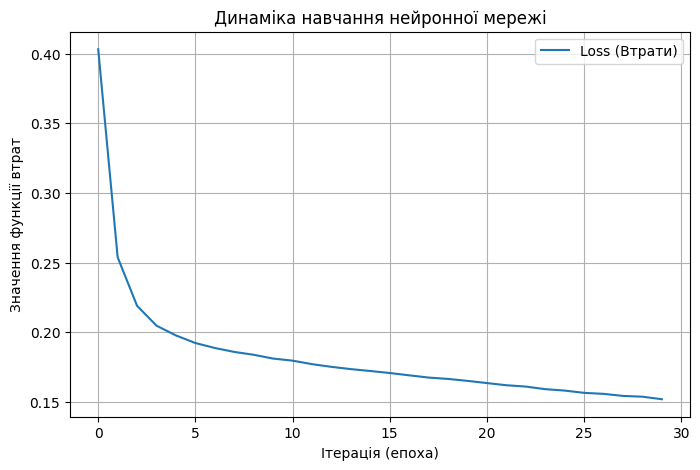

In [7]:
import matplotlib.pyplot as plt

# 11. Оцінка на тестовій множині
loss, accuracy = model.evaluate(X_test, Y_test, verbose=0)
print(f"Точність на тестових даних: {accuracy*100:.2f}%")

# 12. Графік залежності критерію якості від ітерації
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Loss (Втрати)')
plt.title('Динаміка навчання нейронної мережі')
plt.xlabel('Ітерація (епоха)')
plt.ylabel('Значення функції втрат')
plt.legend()
plt.grid(True)
plt.show()

13. Подати на вхід навченої мережі довільний зразок із тестової вибірки. За
результатами вивести наступне повідомлення: «Передбачено клас {мітка класу}
з достовірністю {Р}%».

In [8]:
import numpy as np

# Беремо перший зразок із тестової вибірки
sample_idx = 0
sample = X_test[sample_idx].reshape(1, -1)

# Передбачення
prediction = model.predict(sample, verbose=0)
predicted_class = np.argmax(prediction)
probability = np.max(prediction) * 100

print(f"Передбачено клас {predicted_class} з достовірністю {probability:.2f}%")

Передбачено клас 0 з достовірністю 97.19%
